<a href="https://colab.research.google.com/github/eteitelbaum/code-satp/blob/main/model-data-size-experiments/target_type/exp_targettype.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install transformers datasets torch scikit-learn scikit-multilearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 487.4/487.4 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 23.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 30.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 31.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.4/89.4 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11

In [ ]:
import numpy as np
import pandas as pd
from skmultilearn.model_selection import IterativeStratification

def iterative_train_test_split_custom(X, y, test_size, random_state=None):
    """
    Splits X and y into two sets (train and test) using iterative stratification.
    The test set will have approximately the given test_size fraction of samples.
    """
    stratifier = IterativeStratification(
        n_splits=2,
        order=1,
        sample_distribution_per_fold=[1 - test_size, test_size]
    )
    # The generator returns (train_indices, test_indices)
    for train_idx, test_idx in stratifier.split(X, y):
        return X[test_idx], y[test_idx], X[train_idx], y[train_idx]

def stratified_split(df, x_col, stratify_cols, test_size, val_size=None, random_state=None):
    """
    Splits a DataFrame into stratified sets using iterative stratification.

    Parameters:
      df           : pandas DataFrame.
      x_col        : column name containing the features (e.g., "incident_summary").
      stratify_cols: list of column names to use for stratification.
      train_size   : fraction for training (used for information; priority is given to training and validation).
      test_size    : fraction for test set.
      val_size     : (optional) fraction for validation set. If None, a two-split (train/test) is performed.
      random_state : seed for reproducibility.

    Returns:
      If val_size is None:
         (X_train, y_train, X_test, y_test)
      Else:
         (X_train, y_train, X_val, y_val, X_test, y_test)

    Note: When using a validation set, it is assumed that train_size + test_size + val_size == 1.
    """
    # Shuffle the DataFrame if a random state is provided.
    if random_state is not None:
        df = df.sample(frac=1, random_state=random_state).reset_index(drop=True)

    # Extract features and stratification labels.
    X = df[x_col].values
    y = df[stratify_cols].values

    if val_size is None:
        X_train, y_train, X_test, y_test = iterative_train_test_split_custom(X, y, test_size, random_state)
        return X_train, y_train, X_test, y_test
    else:
        # First, separate out the training data versus the temporary set (which will be split into val and test).
        temp_size = test_size + val_size
        X_train, y_train, X_temp, y_temp = iterative_train_test_split_custom(X, y, temp_size, random_state)

        # Now, split the temporary set into validation and test.
        # The ratio for the test portion of X_temp is: test_size / (test_size + val_size)
        ratio = test_size / temp_size
        X_val, y_val, X_test, y_test = iterative_train_test_split_custom(X_temp, y_temp, ratio, random_state)
        return X_train, y_train, X_val, y_val, X_test, y_test



In [ ]:

# X_train, y_train, X_test, y_test = stratified_split(
#     data,
#     x_col="incident_summary",
#     stratify_cols=[col for col in data.columns if col != "incident_summary"],
#     train_size=0.9,
#     test_size=0.1,
#     val_size=None,
#     random_state=42
# )

# print("=== Train/Test Split ===")
# print("Train incident_summary:", len(X_train))
# print("Test incident_summary:", len(X_test))


# X_train, y_train, X_val, y_val, X_test, y_test = stratified_split(
#     data,
#     x_col="incident_summary",
#     stratify_cols=[col for col in data.columns if col != "incident_summary"],
#     train_size=0.8,
#     test_size=0.1,
#     val_size=0.1,
#     random_state=42
# )
# print("\n=== Train/Validation/Test Split ===")
# print("Train incident_summary:",len(X_train))
# print("Validation incident_summary:",len(X_val) )
# print("Test incident_summary:", len(X_test))


=== Train/Test Split ===
Train incident_summary: 8941
Train labels:
 [[0 0 0 ... 0 0 0]
 [1 0 0 ... 0 0 0]
 [1 0 0 ... 0 0 0]
 ...
 [0 1 0 ... 0 0 0]
 [0 0 0 ... 0 0 1]
 [0 0 0 ... 0 0 1]]
Test incident_summary: 980
Test labels:
 [[0 0 0 ... 1 0 0]
 [1 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 1]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]

=== Train/Validation/Test Split ===
Train incident_summary: 7934
Train labels:
 [[0 0 0 ... 1 0 0]
 [0 0 0 ... 0 0 0]
 [1 0 0 ... 0 0 0]
 ...
 [0 1 0 ... 0 0 0]
 [0 0 0 ... 0 0 1]
 [0 0 0 ... 0 0 1]]
Validation incident_summary: 1000
Validation labels:
 [[1 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
Test incident_summary: 987
Test labels:
 [[1 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 1]
 ...
 [1 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 1]
 [0 0 0 ... 0 0 1]]


In [ ]:
import torch
from torch.utils.data import Dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, hamming_loss, accuracy_score
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

# =======================
# Generalized Dataset Class
# =======================
class MultiLabelDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]
        encoding = self.tokenizer(
            text,
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.float),
        }

# =======================
# Function to Compute Metrics
# =======================
from sklearn.metrics import classification_report, hamming_loss, accuracy_score

def compute_metrics(eval_pred, target_names):
    """
    Compute evaluation metrics for multi-label classification.
    Includes Hamming Loss, Subset Accuracy, and Classification Report for all labels.
    """
    logits, labels = eval_pred
    predictions = (torch.sigmoid(torch.tensor(logits)) > 0.5).numpy()  # Apply threshold
    labels = labels.astype(int)

    # Verify Labels
    print("Shape of labels:", labels.shape)  # Ensures correct dimensions
    print("First few rows of labels:\n", labels[:5])  # Shows the first few rows to check for issues
    print("Final target names:", target_names)

    # Hamming Loss
    hamming = hamming_loss(labels, predictions)

    # Subset Accuracy
    subset_acc = accuracy_score(labels, predictions)

    # Classification Report
    report = classification_report(
        labels, predictions,
        target_names=target_names,
        zero_division=0, output_dict=True
    )

    # Print complete report for reference
    print("\nFull Classification Report:")
    print(classification_report(labels, predictions, target_names=target_names, zero_division=0))


    # Summary Metrics for Trainer
    metrics = {
        "hamming_loss": hamming,
        "subset_accuracy": subset_acc,
    }
    metrics.update(report)
    return metrics

# =======================
# Reusable Training Function
# =======================
def train_transformer_model(model_name, data, max_len=512, test_size=0.1, val_size=0.1, batch_size=40, epochs=3):
    """
    Generalized function to train a transformer model for multi-label classification.
    Args:
        model_name: Name of the pre-trained model (e.g., "bert-base-uncased", "distilbert-base-uncased").
        data: Pandas DataFrame with columns "incident_summary" and multi-label columns.
        max_len: Maximum sequence length.
        batch_size: Batch size for training and evaluation.
        epochs: Number of training epochs.
    """
    # Load tokenizer and model
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSequenceClassification.from_pretrained(
        model_name,
        num_labels=data.shape[1] - 1,  # Number of labels (all columns except "incident_summary")
        problem_type="multi_label_classification",
    )
    model.to("cuda" if torch.cuda.is_available() else "cpu")

    target_names = data.drop(columns=["incident_summary"]).columns.tolist()

    # Split data into train, val, and test
    X = data["incident_summary"]
    y = data.drop('incident_summary', axis=1).values

    # X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42) #stratify=y)
    # X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)




    # X_train, y_train, X_test, y_test = stratified_split(
    #     data,
    #     x_col="incident_summary",
    #     stratify_cols=[col for col in data.columns if col != "incident_summary"],
    #     train_size=0.9,
    #     test_size=0.1,
    #     val_size=None,
    #     random_state=42
    # )



    X_train, y_train, X_val, y_val, X_test, y_test = stratified_split(
        data,
        x_col="incident_summary",
        stratify_cols=[col for col in data.columns if col != "incident_summary"],
        test_size=test_size,
        val_size=val_size,
        random_state=42
    )


    # Create datasets
    train_dataset = MultiLabelDataset(X_train.tolist(), y_train, tokenizer, max_len)
    val_dataset = MultiLabelDataset(X_val.tolist(), y_val, tokenizer, max_len)
    test_dataset = MultiLabelDataset(X_test.tolist(), y_test, tokenizer, max_len)

    # Define training arguments
    training_args = TrainingArguments(
        output_dir="./results",
        eval_strategy="epoch",
        save_strategy="epoch",
        learning_rate=2e-5,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=batch_size,
        num_train_epochs=epochs,
        weight_decay=0.01,
        logging_dir="./logs",
        logging_steps=10,
        load_best_model_at_end=True,
        metric_for_best_model='eval_hamming_loss',
        greater_is_better=True,
        save_total_limit=2,
        report_to="none",
    )

    # Initialize Trainer
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        processing_class=tokenizer,
        compute_metrics=lambda eval_pred: compute_metrics(eval_pred, target_names)
    )

    # Train and Evaluate
    trainer.train()

    # Final Evaluation on Test Set
    test_results = trainer.evaluate(test_dataset)
    print("Test Set Results:", test_results)

    return trainer, test_results


In [ ]:
fraction_labels = {
    1/32: "3%",   # 1/32 = 3.125%
    1/16: "6%",   # 1/16 = 6.25%
    1/8:  "12%",  # 1/8  = 12.5%
    1/4:  "25%",
    1/2:  "50%",
    1.0:  "100%"
}

model_name_labels = {
    "bert-base-cased": "BERT",
    "snowood1/ConfliBERT-scr-cased": "ConfliBERT",
    "FacebookAI/roberta-base": "RoBERTa",
    "distilbert-base-cased": "DistilBERT",
    "xlnet-base-cased": "XLNet",
    "google/electra-base-discriminator": "ELECTRA"
}

fractions = [1/32, 1/16, 1/8, 1/4, 1/2, 1.0]

models_list = [
    "bert-base-cased",
    "snowood1/ConfliBERT-scr-cased",
    "FacebookAI/roberta-base",
    "distilbert-base-cased",
    "xlnet-base-cased",
    "google/electra-base-discriminator"
]

In [ ]:
def run_all_experiments_and_save(df_full, output_csv="experiment_results.csv"):
    """
    1. Iterates over the defined fractions & model list
    2. Samples df_full according to fraction
    3. Trains & evaluates using train_multiclass_model_3way_split
    4. Saves the collected results in a DataFrame
    5. Exports to CSV

    Args:
        df_full (pd.DataFrame): Full dataset with columns [label_col, text_col].
        output_csv (str): File path to save the experiment results.
    Returns:
        results_df (pd.DataFrame): Contains experiment results for analysis.
    """
    results_list = []

    for frac in fractions:
        # Sample a fraction of the data
        subset_size = int(len(df_full) * frac)
        df_subset = df_full.sample(n=subset_size, random_state=42)

        # Friendly fraction label if you want
        frac_label = fraction_labels.get(frac, f"{frac*100:.1f}%")
        print(f"\n=== DATA FRACTION: {frac} ({subset_size} rows) ===")

        for model_name in models_list:
            # Model label
            model_label = model_name_labels.get(model_name, model_name)
            print(f"Training model: {model_label}")

            # Train & evaluate
            # write the model funtion here
            trainer, test_results = train_transformer_model(model_name, df_subset, max_len=512, test_size=0.1, val_size=0.1, batch_size=16, epochs=2)


            # Build a result dict
            run_result = {
                "fraction_raw": frac,
                "fraction_label": frac_label,
                "subset_size": subset_size,
                "model_raw": model_name,
                "model_label": model_label
            }

            # Flatten the nested dictionary
            for key, value in test_results.items():
                if isinstance(value, dict):
                    for subkey, subvalue in value.items():
                        # Create new key names like "armed_assault_precision"
                        run_result[f"{key}_{subkey}"] = subvalue
                else:
                    run_result[key] = value

            # Append to results_list
            results_list.append(run_result)

    # Convert to DataFrame
    results_df = pd.DataFrame(results_list)
    # Save to CSV
    results_df.to_csv(output_csv, index=False)
    print(f"\nResults saved to {output_csv}")

    # also save to JSON
    # results_df.to_json("experiment_results.json", orient="records")

    return results_df




# **Read From Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
data = pd.read_csv('/content/drive/MyDrive/colab/satp-data/target_type.csv')

#**Read from GitHub**

In [ ]:
import pandas as pd

# Corrected URL to access the raw CSV data
url = 'https://raw.githubusercontent.com/eteitelbaum/code-satp/main/model-data-size-experiments/target_type/target_type.csv'

try:
    data = pd.read_csv(url)
    print(data.head())
except Exception as e:
    print(f"Error loading CSV from URL: {e}")

           first_target second_target  civilians  maoist  \
0             Civilians     No Target          1       0   
1             No Target     No Target          0       0   
2                Maoist     No Target          0       1   
3  Government Officials     No Target          0       0   
4      Private Property       Unknown          0       0   

   government_officials  security  private_property  mining_company  ngos  \
0                     0         0                 0               0     0   
1                     0         0                 0               0     0   
2                     0         0                 0               0     0   
3                     1         0                 0               0     0   
4                     0         0                 1               0     0   

   government_infrastructure  ...  first_civilian_target  \
0                          0  ...                    NaN   
1                          0  ...                    NaN

In [ ]:


selected_columns = ['civilians', 'maoist', 'government_officials', 'security', 'private_property', 'mining_company', 'ngos', 'government_infrastructure', 'non_maoist_armed_group', 'no_target', 'incident_summary']
data = data[selected_columns]

# Now 'data' contains only the selected columns.
print(data.head())


   civilians  maoist  government_officials  security  private_property  \
0          1       0                     0         0                 0   
1          0       0                     0         0                 0   
2          0       1                     0         0                 0   
3          0       0                     1         0                 0   
4          0       0                     0         0                 1   

   mining_company  ngos  government_infrastructure  non_maoist_armed_group  \
0               0     0                          0                       0   
1               0     0                          0                       0   
2               0     0                          0                       0   
3               0     0                          0                       0   
4               0     0                          0                       0   

   no_target                                   incident_summary  
0          0  An all

In [ ]:
# import pandas as pd

# def print_label_distribution(y, split_name, stratify_cols):
#     """
#     Prints the count of samples for each label in a given split.

#     Parameters:
#       y            : NumPy array with stratification labels (each column corresponds to a label)
#       split_name   : Name of the split (e.g., "Train", "Test", "Validation")
#       stratify_cols: List of label column names corresponding to the columns in y
#     """
#     df_labels = pd.DataFrame(y, columns=stratify_cols)
#     print(f"Label distribution in {split_name} set:")
#     for col in stratify_cols:
#         print(f"  {col} distribution:")
#         print(df_labels[col].value_counts())
#     print("\n")

# # Example usage after splitting:

# # Assuming 'stratify_cols' is defined as:
# stratify_cols = [col for col in data.columns if col != "incident_summary"]

# # For a two-split (Train/Test) scenario:
# print_label_distribution(y_train, "Train", stratify_cols)
# print_label_distribution(y_test, "Test", stratify_cols)

# # For a three-split (Train/Validation/Test) scenario:
# print_label_distribution(y_train, "Train", stratify_cols)
# print_label_distribution(y_val, "Validation", stratify_cols)
# print_label_distribution(y_test, "Test", stratify_cols)


Label distribution in Train set:
  civilians distribution:
civilians
0    6664
1    1270
Name: count, dtype: int64
  maoist distribution:
maoist
0    4352
1    3582
Name: count, dtype: int64
  government_officials distribution:
government_officials
0    7508
1     426
Name: count, dtype: int64
  security distribution:
security
0    7110
1     824
Name: count, dtype: int64
  private_property distribution:
private_property
0    7425
1     509
Name: count, dtype: int64
  mining_company distribution:
mining_company
0    7880
1      54
Name: count, dtype: int64
  ngos distribution:
ngos
0    7928
1       6
Name: count, dtype: int64
  government_infrastructure distribution:
government_infrastructure
0    7164
1     770
Name: count, dtype: int64
  non_maoist_armed_group distribution:
non_maoist_armed_group
0    7886
1      48
Name: count, dtype: int64
  no_target distribution:
no_target
0    6880
1    1054
Name: count, dtype: int64


Label distribution in Test set:
  civilians distribution:
c

## Run the Models

In [ ]:

# Example usage:
final_results_df = run_all_experiments_and_save(data, output_csv="experiment_results.csv")

# Now you can inspect final_results_df in Python:
print(final_results_df.head())

# If you want to do more analysis, you can pivot, group, or plot the data.



=== DATA FRACTION: 0.03125 (310 rows) ===
Training model: BERT


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1594: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss,Hamming Loss,Subset Accuracy,Civilians,Maoist,Government Officials,Security,Private Property,Mining Company,Ngos,Government Infrastructure,Non Maoist Armed Group,No Target,Micro avg,Macro avg,Weighted avg,Samples avg,Runtime,Samples Per Second,Steps Per Second
1,0.669600,0.512377,0.141935,0.225806,"{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 5.0}","{'precision': 0.45161290322580644, 'recall': 1.0, 'f1-score': 0.6222222222222222, 'support': 14.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 1.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 3.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 3.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 0.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 0.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 3.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 0.0}","{'precision': 0.29411764705882354, 'recall': 1.0, 'f1-score': 0.45454545454545453, 'support': 5.0}","{'precision': 0.3958333333333333, 'recall': 0.5588235294117647, 'f1-score': 0.4634146341463415, 'support': 34.0}","{'precision': 0.074573055028463, 'recall': 0.2, 'f1-score': 0.10767676767676768, 'support': 34.0}","{'precision': 0.22921084942515904, 'recall': 0.5588235294117647, 'f1-score': 0.32305407011289367, 'support': 34.0}","{'precision': 0.41935483870967744, 'recall': 0.6129032258064516, 'f1-score': 0.4838709677419354, 'support': 34.0}",1.067600,29.038000,1.873000
2,0.461200,0.431452,0.119355,0.451613,"{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 5.0}","{'precision': 0.45161290322580644, 'recall': 1.0, 'f1-score': 0.6222222222222222, 'support': 14.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 1.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 3.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 3.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 0.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 0.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 3.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 0.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 5.0}","{'precision': 0.45161290322580644, 'recall': 0.4117647058823529, 'f1-score': 0.4307692307692308, 'support': 34.0}","{'precision': 0.04516129032258064, 'recall': 0.1, 'f1-score': 0.06222222222222222, 'support': 34.0}","{'precision': 0.1859582542694497, 'recall': 0.4117647058823529, 'f1-score': 0.2562091503267974, 'support': 34.0}","{'precision': 0.45161290322580644, 'recall': 0.45161290322580644, 'f1-score': 0.45161290322580644, 'support': 34.0}",1.051200,29.491000,1.903000


Shape of labels: (31, 10)
First few rows of labels:
 [[0 0 0 0 0 0 0 0 0 1]
 [0 1 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1]
 [0 1 0 0 0 0 0 0 0 0]]
Final target names: ['civilians', 'maoist', 'government_officials', 'security', 'private_property', 'mining_company', 'ngos', 'government_infrastructure', 'non_maoist_armed_group', 'no_target']

Full Classification Report:
                           precision    recall  f1-score   support

                civilians       0.00      0.00      0.00         5
                   maoist       0.45      1.00      0.62        14
     government_officials       0.00      0.00      0.00         1
                 security       0.00      0.00      0.00         3
         private_property       0.00      0.00      0.00         3
           mining_company       0.00      0.00      0.00         0
                     ngos       0.00      0.00      0.00         0
government_infrastructure       0.00      0.00      0.00         3
   n

Shape of labels: (31, 10)
First few rows of labels:
 [[0 1 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 1 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0]]
Final target names: ['civilians', 'maoist', 'government_officials', 'security', 'private_property', 'mining_company', 'ngos', 'government_infrastructure', 'non_maoist_armed_group', 'no_target']

Full Classification Report:
                           precision    recall  f1-score   support

                civilians       0.00      0.00      0.00         5
                   maoist       0.45      1.00      0.62        14
     government_officials       0.00      0.00      0.00         2
                 security       0.00      0.00      0.00         3
         private_property       0.00      0.00      0.00         1
           mining_company       0.00      0.00      0.00         0
                     ngos       0.00      0.00      0.00         0
government_infrastructure       0.00      0.00      0.00         3
   n

...

Shape of labels: (126, 10)
First few rows of labels:
 [[0 1 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0]]
Final target names: ['civilians', 'maoist', 'government_officials', 'security', 'private_property', 'mining_company', 'ngos', 'government_infrastructure', 'non_maoist_armed_group', 'no_target']

Full Classification Report:
                           precision    recall  f1-score   support

                civilians       0.00      0.00      0.00        22
                   maoist       0.93      0.71      0.80        55
     government_officials       0.00      0.00      0.00         6
                 security       0.00      0.00      0.00        12
         private_property       0.00      0.00      0.00         8
           mining_company       0.00      0.00      0.00         1
                     ngos       0.00      0.00      0.00         0
government_infrastructure       0.00      0.00      0.00        13
   

Shape of labels: (124, 10)
First few rows of labels:
 [[1 0 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 1]
 [0 1 0 0 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0]]
Final target names: ['civilians', 'maoist', 'government_officials', 'security', 'private_property', 'mining_company', 'ngos', 'government_infrastructure', 'non_maoist_armed_group', 'no_target']

Full Classification Report:
                           precision    recall  f1-score   support

                civilians       0.00      0.00      0.00        22
                   maoist       0.95      0.65      0.77        54
     government_officials       0.00      0.00      0.00         7
                 security       0.00      0.00      0.00        12
         private_property       0.00      0.00      0.00         9
           mining_company       0.00      0.00      0.00         1
                     ngos       0.00      0.00      0.00         0
government_infrastructure       0.00      0.00      0.00        12
   

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at FacebookAI/roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
/usr/local/lib/python3.11/dist-packages/transformers/training_args.py:1594: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


Epoch,Training Loss,Validation Loss,Hamming Loss,Subset Accuracy,Civilians,Maoist,Government Officials,Security,Private Property,Mining Company,Ngos,Government Infrastructure,Non Maoist Armed Group,No Target,Micro avg,Macro avg,Weighted avg,Samples avg,Runtime,Samples Per Second,Steps Per Second
1,0.281100,0.250611,0.076984,0.388889,"{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 22.0}","{'precision': 0.7777777777777778, 'recall': 0.8909090909090909, 'f1-score': 0.8305084745762712, 'support': 55.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 6.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 12.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 8.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 1.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 0.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 13.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 0.0}","{'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 15.0}","{'precision': 0.7777777777777778, 'recall': 0.3712121212121212, 'f1-score': 0.5025641025641026, 'support': 132.0}","{'precision': 0.07777777777777778, 'recall': 0.08909090909090908, 'f1-score': 0.08305084745762711, 'support': 132.0}","{'precision': 0.32407407407407407, 'recall': 0.3712121212121212, 'f1-score': 0.346045197740113, 'support': 132.0}","{'precision': 0.3888888888888889, 'recall': 0.3888888888888889, 'f1-score': 0.3888888888888889, 'support': 132.0}",3.588400,35.113000,2.229000


Shape of labels: (126, 10)
First few rows of labels:
 [[0 1 0 0 0 0 0 0 0 0]
 [0 0 0 1 0 0 0 0 0 0]
 [0 1 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 1 0 0]]
Final target names: ['civilians', 'maoist', 'government_officials', 'security', 'private_property', 'mining_company', 'ngos', 'government_infrastructure', 'non_maoist_armed_group', 'no_target']

Full Classification Report:
                           precision    recall  f1-score   support

                civilians       0.00      0.00      0.00        22
                   maoist       0.78      0.89      0.83        55
     government_officials       0.00      0.00      0.00         6
                 security       0.00      0.00      0.00        12
         private_property       0.00      0.00      0.00         8
           mining_company       0.00      0.00      0.00         1
                     ngos       0.00      0.00      0.00         0
government_infrastructure       0.00      0.00      0.00        13
   

## Commit Results to GitHub

In [ ]:
# commit csv to github using python

from github import Github
import pandas as pd
import os

# Replace with your GitHub personal access token
g = Github("your_github_access_token")

# Replace with your repository name and owner
repo = g.get_user("your_github_username").get_repo("your_repository_name")

# Specify the path to the CSV file in your Colab environment
csv_file_path = "experiment_results.csv"

# Check if the file exists
if not os.path.exists(csv_file_path):
    print(f"Error: CSV file '{csv_file_path}' not found.")
else:
    # Create a file object and commit
    try:
        with open(csv_file_path, 'rb') as file_obj:
            contents = repo.create_file(
                path="experiment_results.csv",  # Specify the path in your repository
                message="Committing CSV file from Colab",
                content=file_obj.read(),
                branch="main"  # Replace with your branch name
            )
        print("CSV file successfully committed to GitHub!")
    except Exception as e:
        print(f"Error committing CSV file to GitHub: {e}")


## Save to Disc

In [ ]:
import os


def save_to_drive(df, filename, folder_name="targettype"):
    base_path = "/content/drive/MyDrive/colab/satp-results/"
    drive_path = os.path.join(base_path, folder_name)

    # Create the folder if it doesn't exist
    if not os.path.exists(drive_path):
        os.makedirs(drive_path)

    filepath = os.path.join(drive_path, filename)
    df.to_csv(filepath, index=False)
    print(f"✅ DataFrame saved to: {filepath}")

save_to_drive(final_results_df, "targettype_results.csv")


## Analyze Results

In [5]:
#mount drive
from google.colab import drive
drive.mount('/content/drive')

#read csv from drive
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/colab/satp-results/targettype/targettype_results.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### F1 Micro

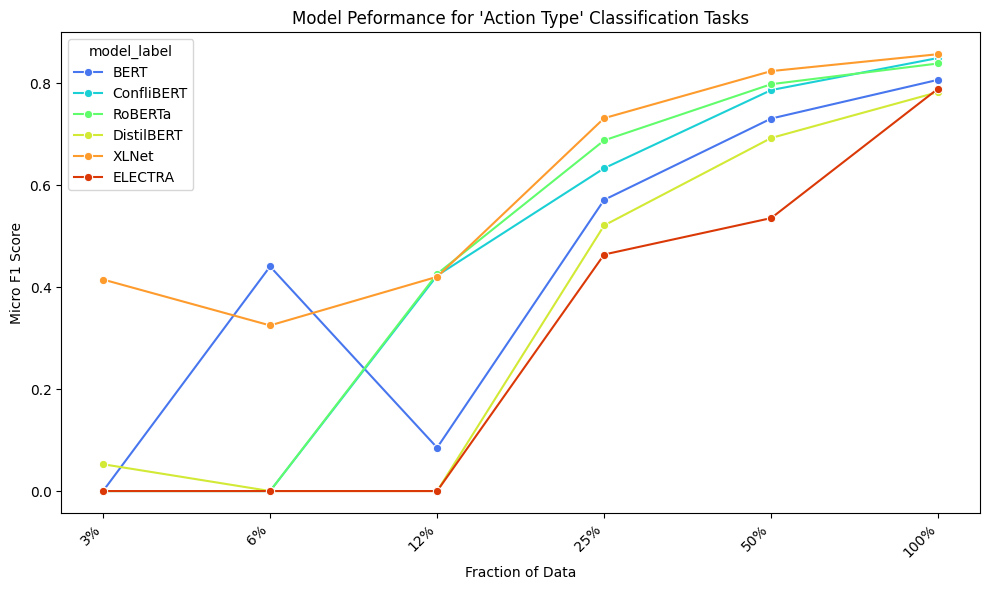

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the plot
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=df,
    x="fraction_label",
    y="eval_micro avg_f1-score",
    hue="model_label",
    marker="o",
    palette="turbo"
    )

# Customize the plot
plt.xlabel("Fraction of Data")
plt.ylabel("Micro F1 Score")
plt.title("Model Peformance for 'Target Type' Classification Tasks")
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

### Heatmap of individual labels

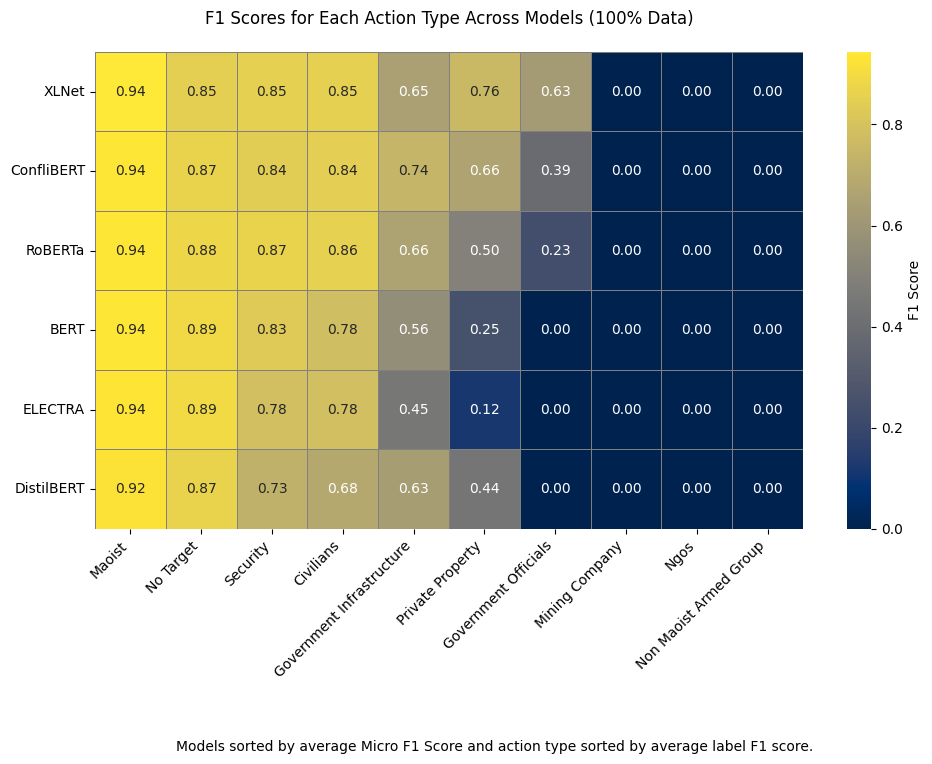

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Filter the dataset for models trained on 100% of the data
df_100 = df[df["fraction_label"] == "100%"]

# Extract F1-score columns related to specific labels (excluding averages)
label_f1_columns = [col for col in df_100.columns if col.startswith("eval_") and "_f1-score" in col and "avg" not in col]

# Select only the relevant columns along with the model label
df_f1_100 = df_100[["model_label"] + label_f1_columns]

# Rename "ConfliBERT-scr-cased" to "ConfliBERT" for clarity
#df_f1_100["model_label"] = df_f1_100["model_label"].replace({"ConfliBERT-scr-cased": "ConfliBERT"})

# Convert data to long format for heatmap visualization
df_f1_melted_100 = df_f1_100.melt(id_vars=["model_label"], var_name="Label", value_name="F1 Score")

# Clean label names (remove "eval_" prefix and "_f1-score" suffix for readability)
df_f1_melted_100["Label"] = df_f1_melted_100["Label"].str.replace("eval_", "").str.replace("_f1-score", "").str.replace("_", " ").str.title()

# Pivot the table so that models are on the y-axis and event types on the x-axis
df_f1_pivot_100 = df_f1_melted_100.pivot(index="model_label", columns="Label", values="F1 Score")

# Remove "Incident Summary" if it exists
df_f1_pivot_100 = df_f1_pivot_100.drop(columns="Incident Summary", errors="ignore")

# Sort event types (columns) by their average F1 score across models (descending order)
event_order = df_f1_pivot_100.mean().sort_values(ascending=False).index
df_f1_pivot_100 = df_f1_pivot_100[event_order]

# Sort models (rows) by their Micro F1 score (descending order) while ensuring all models are included
df_model_avg_f1 = df_100.set_index("model_label")["eval_micro avg_f1-score"].sort_values(ascending=False)
model_order = df_model_avg_f1.index
df_f1_pivot_100 = df_f1_pivot_100.loc[model_order]

# Plot the heatmap
plt.figure(figsize=(10, 7))
ax = sns.heatmap(df_f1_pivot_100, annot=True, fmt=".2f", cmap="cividis", linewidths=0.5, linecolor="gray", cbar_kws={'label': 'F1 Score'})

# Customize the plot
ax.set_title("F1 Scores for Each Target Type Across Models (100% Data)", pad=20)

# Add a custom note
plt.figtext(0.5, -0.08,
            "Models sorted by average Micro F1 Score and action type sorted by average label F1 score.",
            ha="center", fontsize=10)

# Remove X and Y axis labels
ax.set_xlabel("")
ax.set_ylabel("")

# Move event type labels (x-axis) to the bottom
ax.xaxis.tick_bottom()
ax.xaxis.set_label_position('bottom')

# Adjust ticks
plt.xticks(rotation=45, ha="right")  # Rotate labels for readability
plt.yticks(rotation=0)

# Show the heatmap
plt.tight_layout()
plt.show()


### Model performance vs. speed

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

def scatter_plot_speed_vs_accuracy(df, x_col, y_col, hue_col, size_col, title):
    """
    Creates a scatter (bubble) plot with customizable x and y axes.

    Parameters:
    - df: DataFrame containing the data
    - x_col: Column name for the x-axis (e.g., throughput, latency)
    - y_col: Column name for the y-axis (e.g., accuracy, latency)
    - hue_col: Column name for the hue (color grouping, e.g., model name)
    - size_col: Column name for the size (bubble size, e.g., data fraction)
    - title: Custom plot title
    """

    # Initialize figure
    plt.figure(figsize=(7, 5))

    # Create scatterplot with Seaborn
    scatter = sns.scatterplot(
        data=df,
        x=x_col,
        y=y_col,
        hue=hue_col,   # Color by model
        size=size_col,  # Bubble size by fraction
        sizes=(20, 400),  # Min to max size of markers
        alpha=0.7,  # Partial transparency
        palette="turbo"
    )

    # Clean up axis labels: Remove "eval_" prefix if present
    x_label_cleaned = x_col.replace("eval_", "").replace("_", " ").title()
    y_label_cleaned = y_col.replace("eval_", "").replace("_", " ").title()

    # Labeling
    scatter.set_title(title)
    scatter.set_xlabel(x_label_cleaned)  # Use cleaned x-axis label
    scatter.set_ylabel(y_label_cleaned)  # Use cleaned y-axis label

    # Retrieve the current legend handles and labels
    handles, labels = scatter.get_legend_handles_labels()

    # Convert column values to string for correct matching
    model_names = df[hue_col].astype(str).unique()
    fraction_values = sorted(df[size_col].astype(str).unique())

    # Filter legend items dynamically
    hue_handles = [h for h, l in zip(handles, labels) if l in model_names]
    hue_labels = [l for l in labels if l in model_names]

    size_handles = [h for h, l in zip(handles, labels) if l in fraction_values]
    size_labels = [l for l in labels if l in fraction_values]

    # Create the updated legends
    hue_legend = plt.legend(hue_handles, hue_labels, title="Model Name", loc="upper left", bbox_to_anchor=(1.05, 1))
    plt.gca().add_artist(hue_legend)  # Ensure the first legend stays

    size_legend = plt.legend(size_handles, size_labels, title="Fraction Raw", loc="lower left", bbox_to_anchor=(1.05, 0))

    # Show the plot
    plt.tight_layout()
    plt.show()


### Micro F1 vs. samples per second

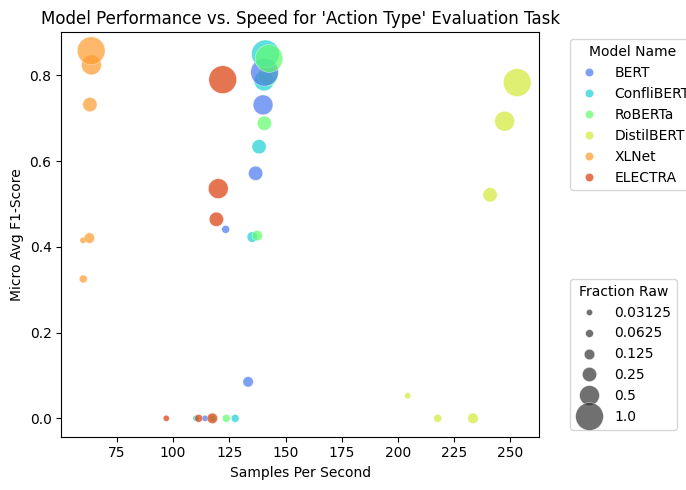

In [10]:
scatter_plot_speed_vs_accuracy(
    df=df,
    x_col="eval_samples_per_second",
    y_col="eval_micro avg_f1-score",
    hue_col="model_label",
    size_col="fraction_raw",
    title="Model Performance vs. Speed for 'Target Type' Evaluation Task"
)